In [8]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Polygon
from transformers import pipeline
from dotenv import load_dotenv
load_dotenv()

from faro import FaroSceneGraphReader
from delaunay import get_delaunay_centerlines, HAS_NUMBA
from traj import (
    OrientedBoundingBox,
    extract_vehicle_chronology,
    get_vehicle_heading,
)
from som import identify_lane_connections

%matplotlib widget
%load_ext autoreload
%autoreload 2

try:
    if string_table:
        pass
except NameError:
    string_table = {}

clf_pipeline = pipeline(
    "zero-shot-classification",
    model="sileod/deberta-v3-large-tasksource-nli",
    local_files_only=True,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Device set to use mps:0


In [9]:
folder = '../data/nhtsa-ciss/data/output/'
# load random .far file from folder
far_files = [f for f in os.listdir(folder) if f.endswith('.far')]
filename = random.choice(far_files)
# filename = '23103_20211031066.far'
# filename = '22186_20211027049.far'

# filename = '22012_20211052088.far'
# filename = '21137_20211020024.far'
# filename = '21647_20211022054.far'
# filename = '20544_20211020005.far'
# filename = '27208_20221010147.far'
# filename = '28136_20221019168.far'
# filename = '25922_20221019074.far'
# filename = '21670_20211048031.far'
# filename = '26217_20221059035.far'
# filename = '25486_20221052042.far'
# filename = '26808_20221052111.far'
# filename = '27014_20221018071.far'
# filename = '28274_20221020227.far'
# filename = '25486_20221052042.far'
# filename = '27256_20221059066.far'
# filename = '20407_20211077002.far' # Polyline instead of symbol for cars
# filename = '25962_20221018041.far'

# filename = '22362_20211032077.far'  # splitting test
filename = '21802_20211059022.far'

file = os.path.join(folder, filename)
print(f"Loading file: {file}")
print(f"https://crashviewer.nhtsa.dot.gov/ciss/details/{filename.split('_')[0]}/crash-summary-scene-diagram")
reader = FaroSceneGraphReader(file, clf_pipeline, cls_cache=string_table)
scene = reader.parse()
print(len(scene["vehicles"]))

# %%
print(f"Numba JIT available: {HAS_NUMBA}")

Loading file: ../data/nhtsa-ciss/data/output/21802_20211059022.far
https://crashviewer.nhtsa.dot.gov/ciss/details/21802/crash-summary-scene-diagram
Extracted 27 primitives and 23 symbols.
Classifying symbols for vehicle candidates...
11
Numba JIT available: True


Centerline lengths: min=6.603716182309545, max=36.0


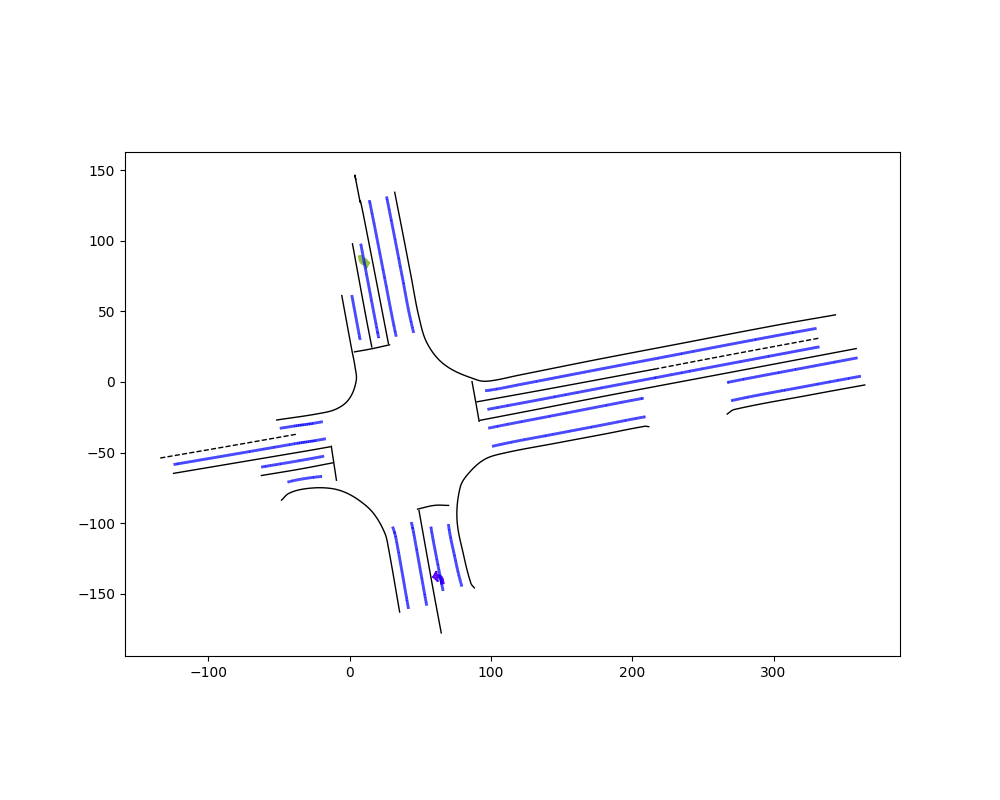

In [10]:
# ============================================================================
# SCENE VISUALIZATION
# ============================================================================
result_centerlines = get_delaunay_centerlines(
    scene["roadway"],
    road_threshold=(8, 36.0),
    vertex_cluster_threshold=10,
    parallel_angle_epsilon=15.0
)

centerline_segments = result_centerlines["centerlines"]
centroid_segments = result_centerlines["skeleton_segments"]
midpoints = result_centerlines["midpoints"]
debug = result_centerlines["debug"]

def draw_symbol(ax, item, color=None):
    if color is None:
        color = np.random.rand(3)
    if item["type"] == "symbol":
        for item in item['items']:
            if item['type'] == 'symbol':
                for subitem in item['items']:
                    verts = subitem["transformed_verts"]
                    xs, ys = zip(*verts)
                    ax.plot(xs, ys, color=color)
            else:
                verts = item["transformed_verts"]
                xs, ys = zip(*verts)
                ax.plot(xs, ys, color=color)
    else:
        verts = item["transformed_verts"]
        xs, ys = zip(*verts)
        ax.plot(xs, ys, color=color)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)



for item in scene["roadway"]:
    verts = item["verts"]
    color = 'black'
    xs, ys = zip(*verts)
    dashed = item.get("dashed", False)
    closed = item.get("closed", False)
    thick = item.get("thick", False)
    if dashed:
        ax.plot(xs, ys, color=color, linestyle='--', linewidth=2 if thick else 1)
    else:
        ax.plot(xs, ys, color=color, linewidth=2 if thick else 1)
        if closed:
            ax.fill(xs, ys, color='lightgray', alpha=0.5)

# Calculate min and max lengths from centerline_segments
if centerline_segments:
    all_lengths = [point[2] for line in centerline_segments for point in line]
    min_length = min(all_lengths)
    max_length = max(all_lengths)
    color = False
    # Prepare segments and their corresponding lengths for coloring
    segments = []
    segment_lengths = []
    for line in centerline_segments:
        for i in range(len(line) - 1):
            x0, y0, l0 = line[i]
            x1, y1, l1 = line[i + 1]
            segments.append([[x0, y0], [x1, y1]])
            # Use the average length for the segment color
            segment_lengths.append((l0 + l1) / 2)
    if color:
        norm_center = plt.Normalize(vmin=min_length, vmax=max_length)
        colors_center = plt.cm.viridis(norm_center(segment_lengths))
        lc_center = LineCollection(segments, colors=colors_center, linewidths=2, alpha=0.9, zorder=10, label='Centerline segments')
        sm_center = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm_center)
        fig.colorbar(sm_center, ax=ax, label='Road width (ft)')
    else:
        lc_center = LineCollection(segments, color='blue', linewidths=2, alpha=0.9, zorder=10, label='Centerline segments')
        
    ax.add_collection(lc_center)
    print(f"Centerline lengths: min={min_length}, max={max_length}")

debug_draw = False

if debug_draw:
    triangle_segments = debug["triangle_segments"]
    clustered_triangles = debug["clustered_triangles"]
    non_parallel_triangles = debug["non_parallel_triangles"]
    vertex_cluster_info = debug["vertex_cluster_info"]
    debug_points = debug["all_points"]
    centerline_points = debug["all_centerline_points"]

    if centroid_segments:
        lengths = np.array([np.linalg.norm(np.asarray(a) - np.asarray(b)) for a, b in centroid_segments])
        if len(lengths) == 0:
            lc_cent = LineCollection(centroid_segments, colors='green', linewidths=1, alpha=0.3)
        else:
            vmin, vmax = lengths.min(), lengths.max()
            norm = plt.Normalize(vmin=vmin, vmax=vmax)
            cmap = plt.cm.viridis
            colors_cent = cmap(norm(lengths))
            lc_cent = LineCollection(centroid_segments, colors=colors_cent, linewidths=1, alpha=0.3, label='Centroid connections')
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            fig.colorbar(sm, ax=ax, label='centroid edge length')
        ax.add_collection(lc_cent)
    if triangle_segments:
        lengths_tri = np.array([np.linalg.norm(np.asarray(a) - np.asarray(b)) for a, b in triangle_segments])
        if len(lengths_tri) == 0:
            lc_tri = LineCollection(triangle_segments, colors='green', linewidths=0.5, alpha=0.6, label='Valid triangles (parallel)')
        else:
            vmin_tri, vmax_tri = lengths_tri.min(), lengths_tri.max()
            norm_tri = plt.Normalize(vmin=vmin_tri, vmax=vmax_tri)
            cmap_tri = plt.cm.viridis
            colors_tri = cmap_tri(norm_tri(lengths_tri))
            lc_tri = LineCollection(triangle_segments, colors=colors_tri, linewidths=0.5, alpha=0.6, label='Valid triangles (parallel)')
            sm_tri = plt.cm.ScalarMappable(cmap=cmap_tri, norm=norm_tri)
            fig.colorbar(sm_tri, ax=ax, label='triangle edge length')
        ax.add_collection(lc_tri)

    # if clustered_triangles:
    #     lc_clustered = LineCollection(clustered_triangles, colors='red', linewidths=1, alpha=0.5, label='Clustered triangles (filtered)')
    #     ax.add_collection(lc_clustered)

    # if debug["oversized_triangles"]:
    #     lc_oversized = LineCollection(debug["oversized_triangles"], colors='pink', linewidths=1, alpha=0.5, label='oversized triangles (width rejected)')
    #     ax.add_collection(lc_oversized)
    
    # if debug["undersized_triangles"]:
    #     lc_undersized = LineCollection(debug["undersized_triangles"], colors='purple', linewidths=1, alpha=0.5, label='Undersized triangles (width rejected)')
    #     ax.add_collection(lc_undersized)

    # if non_parallel_triangles:
    #     lc_non_parallel = LineCollection(non_parallel_triangles, colors='orange', linewidths=1, alpha=0.5, label='Non-parallel triangles (filtered)')
    #     ax.add_collection(lc_non_parallel)

    # if vertex_cluster_info:
    #     problematic_verts = [(debug_points[v_idx], count) for v_idx, count in vertex_cluster_info.items() if count >= 10]
    #     if problematic_verts:
    #         verts, counts = zip(*problematic_verts)
    #         ax.scatter(*zip(*verts), color='darkred', s=100, marker='*', zorder=13,
    #                 label=f'Cluster centers ({len(verts)} vertices)', edgecolors='yellow', linewidths=1)
    if centerline_points:
        ax.scatter(*zip(*centerline_points), color='blue', s=5, marker='x', zorder=12,
                label=f'All Points ({len(centerline_points)} points)')

    # if midpoints:
    #     ax.scatter(*zip(*midpoints), color='blue', s=5, marker='x', zorder=12,
    #             label=f'Midpoints ({len(midpoints)} points)')


# colors = plt.colormaps['Set1']
# for item in scene["vehicles"]:
#     color = np.random.rand(3,)
#     if item["associated_text"]:
#         veh_no = item["associated_text"][0]
#         if veh_no.isdigit():
#             color = colors(int(veh_no) % 5)
#         else:
#             color = np.random.rand(3,)
#     draw_symbol(ax, item, color=color)
#     cx, cy = item["transformed_center"]
#     ax.plot(cx, cy, 'o', color=color)

for item in scene["road_markings"]:
    if not item["name"]:
        continue
    draw_symbol(ax, item)

# ax.axis('off')
ax.set_aspect('equal', 'box')

In [11]:
# ============================================================================
# VEHICLE TRAJECTORY EXTRACTION (TSP)
# ===========================================================================

PRE_CRASH_ONLY = True  # Set to True: clothoid-only up to first crash, no post-collision fitting

result = extract_vehicle_chronology(scene, pre_crash_only=PRE_CRASH_ONLY)

print(f"\n=== TSP TRAJECTORY ORDERING RESULTS ===")
print(f"Number of vehicle groups: {len(result['trajectories'])}")
print(f"Mode: {'pre-crash only (clothoid)' if PRE_CRASH_ONLY else 'full hybrid (clothoid + spline)'}")

for label, positions in result['trajectories'].items():
    print(f"\nVehicle {label}: {len(positions)} positions")
    print(f"  TSP path score: {result['scores'][label]:.2f}")
    for i, pos in enumerate(positions):
        heading = np.degrees(get_vehicle_heading(pos))
        print(f"    [{i}] center={pos['transformed_center']}, heading={heading:.1f} deg")

if result['first_collisions']:
    fc = result['first_collisions']
    print(f"\n=== FIRST COLLISIONS (per vehicle) ===")
    for label, c in fc['per_vehicle'].items():
        idx = c['indices'][0] if c['vehicles'][0] == label else c['indices'][1]
        other = c['vehicles'][1] if c['vehicles'][0] == label else c['vehicles'][0]
        print(f"  Vehicle {label}: first collision at index {idx} with Vehicle {other} (penetration={c['penetration']:.2f})")
    print(f"  Unique collision events: {len(fc['unique_collisions'])}")
else:
    print("\nNo collision detected between any vehicle positions.")


=== TSP TRAJECTORY ORDERING RESULTS ===
Number of vehicle groups: 2
Mode: pre-crash only (clothoid)

Vehicle 1: 3 positions
  TSP path score: 184.46
    [0] center=(np.float64(187.023052744381), np.float64(11.5147633009881)), heading=-169.5 deg
    [1] center=(np.float64(106.295730131116), np.float64(-4.56004333310276)), heading=-169.4 deg
    [2] center=(np.float64(43.408569335938), np.float64(-14.5976028442378)), heading=-171.1 deg

Vehicle 2: 3 positions
  TSP path score: 181.51
    [0] center=(np.float64(67.7688903808593), np.float64(-165.977294683456)), heading=100.6 deg
    [1] center=(np.float64(56.1558074951171), np.float64(-100.97413611412)), heading=100.8 deg
    [2] center=(np.float64(37.8446960449218), np.float64(-25.3760983943939)), heading=106.7 deg

=== FIRST COLLISIONS (per vehicle) ===
  Vehicle 1: first collision at index 2 with Vehicle 2 (penetration=2.59)
  Vehicle 2: first collision at index 2 with Vehicle 1 (penetration=2.59)
  Unique collision events: 1


/var/folders/72/h38r8kkd0px6b447vc2dj3240000gn/T/ipykernel_42837/3958295185.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vehicle_colors = plt.cm.get_cmap('tab10', len(result['trajectories']))


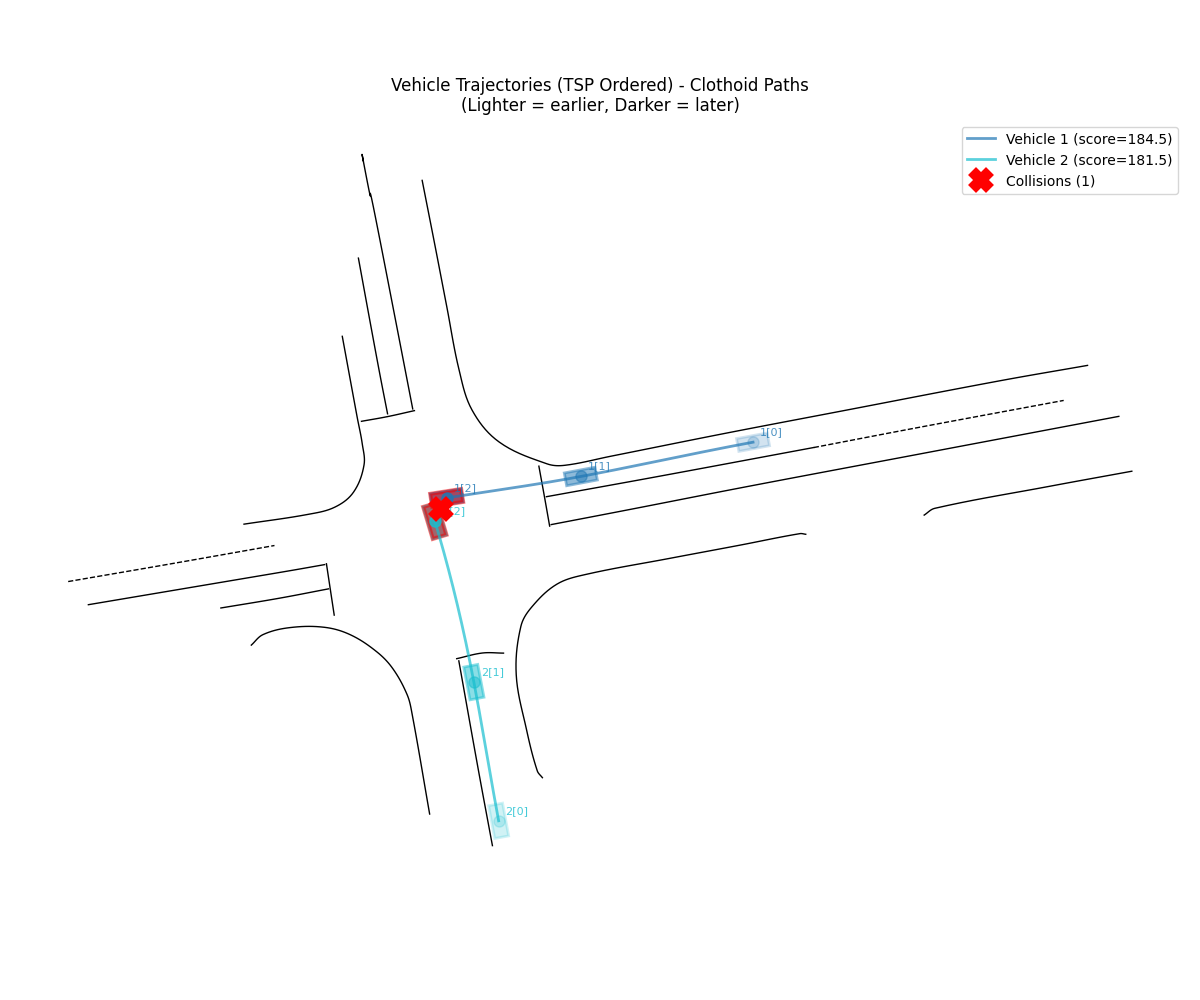

In [12]:
# ============================================================================
# VISUALIZATION: Ordered trajectories with OBBs (TSP ordering)
# ============================================================================

def draw_obb(ax, obb, color='blue', alpha=0.3, linewidth=1):
    """Draw an OBB on the matplotlib axis."""
    corners = obb.get_corners()
    polygon = Polygon(corners, closed=True, fill=True,
                      facecolor=color, edgecolor=color,
                      alpha=alpha, linewidth=linewidth)
    ax.add_patch(polygon)
    return polygon

if 'result' in dir() and result is not None:
    fig, ax = plt.subplots(figsize=(12, 10))

    # Draw roadway
    for item in scene["roadway"]:
        verts = item["verts"]
        xs, ys = zip(*verts)
        dashed = item.get("dashed", False)
        closed = item.get("closed", False)
        if dashed:
            ax.plot(xs, ys, color='black', linestyle='--', linewidth=1)
        else:
            ax.plot(xs, ys, color='black', linewidth=1)
            if closed:
                ax.fill(xs, ys, color='lightgray', alpha=0.3)

    # Build per-vehicle collision cutoff index from first_collisions
    collision_cutoffs = {}
    if result['first_collisions']:
        fc = result['first_collisions']
        for label, c in fc['per_vehicle'].items():
            idx = c['indices'][0] if c['vehicles'][0] == label else c['indices'][1]
            collision_cutoffs[label] = idx

    # Color maps for different vehicles
    vehicle_colors = plt.cm.get_cmap('tab10', len(result['trajectories']))
    # Draw each vehicle's trajectory UP TO the first collision
    for vid, (label, positions) in enumerate(result['trajectories'].items()):
        base_color = vehicle_colors(vid)
        n_positions = len(positions)

        # Determine cutoff index if this vehicle is involved in collision
        max_index = collision_cutoffs.get(label, n_positions - 1)

        # Create gradient from light to dark
        for i, pos in enumerate(positions):
            if i > max_index:
                continue

            alpha = 0.2 + 0.6 * (i / max(1, n_positions - 1))

            obb = OrientedBoundingBox.from_vehicle_symbol(pos)
            draw_obb(ax, obb, color=base_color, alpha=alpha, linewidth=2)

            cx, cy = pos["transformed_center"]
            ax.plot(cx, cy, 'o', color=base_color, markersize=8,
                    alpha=alpha, zorder=10)

            ax.annotate(f"{label}[{i}]", (cx, cy),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=8, color=base_color, alpha=0.8)

        # Draw clothoid trajectory curve instead of straight lines
        if label in result['connected']:
            cx_list, cy_list = result['connected'][label]
            if cx_list and cy_list:
                ax.plot(cx_list, cy_list, '-', color=base_color, linewidth=2,
                        alpha=0.7, zorder=5,
                        label=f'Vehicle {label} (score={result["scores"][label]:.1f})')

    # Highlight collision points (all unique first-collision events)
    if result['first_collisions']:
        for c in result['first_collisions']['unique_collisions']:
            # Draw collision OBBs with red
            draw_obb(ax, c['obb1'], color='red', alpha=0.5, linewidth=3)
            draw_obb(ax, c['obb2'], color='red', alpha=0.5, linewidth=3)

            # Draw midpoint
            collision_center = (c['obb1'].center + c['obb2'].center) / 2
            ax.plot(collision_center[0], collision_center[1], 'X',
                    color='red', markersize=15, markeredgewidth=3,
                    zorder=20)

        # Single legend entry for collisions
        ax.plot([], [], 'X', color='red', markersize=15, markeredgewidth=3,
                label=f'Collisions ({len(result["first_collisions"]["unique_collisions"])})')

    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.legend(loc='upper right')
    ax.set_title('Vehicle Trajectories (TSP Ordered) - Clothoid Paths\n(Lighter = earlier, Darker = later)')
    plt.tight_layout()
    plt.show()
else:
    print("No trajectory results to visualize. Run the extraction cell first.")

Extracted 36 total endpoints from centerlines
LaneEndpoint(id=0, x=np.float64(-124.558934242044), y=np.float64(-58.430454626764956), heading=np.float64(-2.972356289656633), lane_idx=0)
Total endpoints: 36
Intersection endpoints: 32


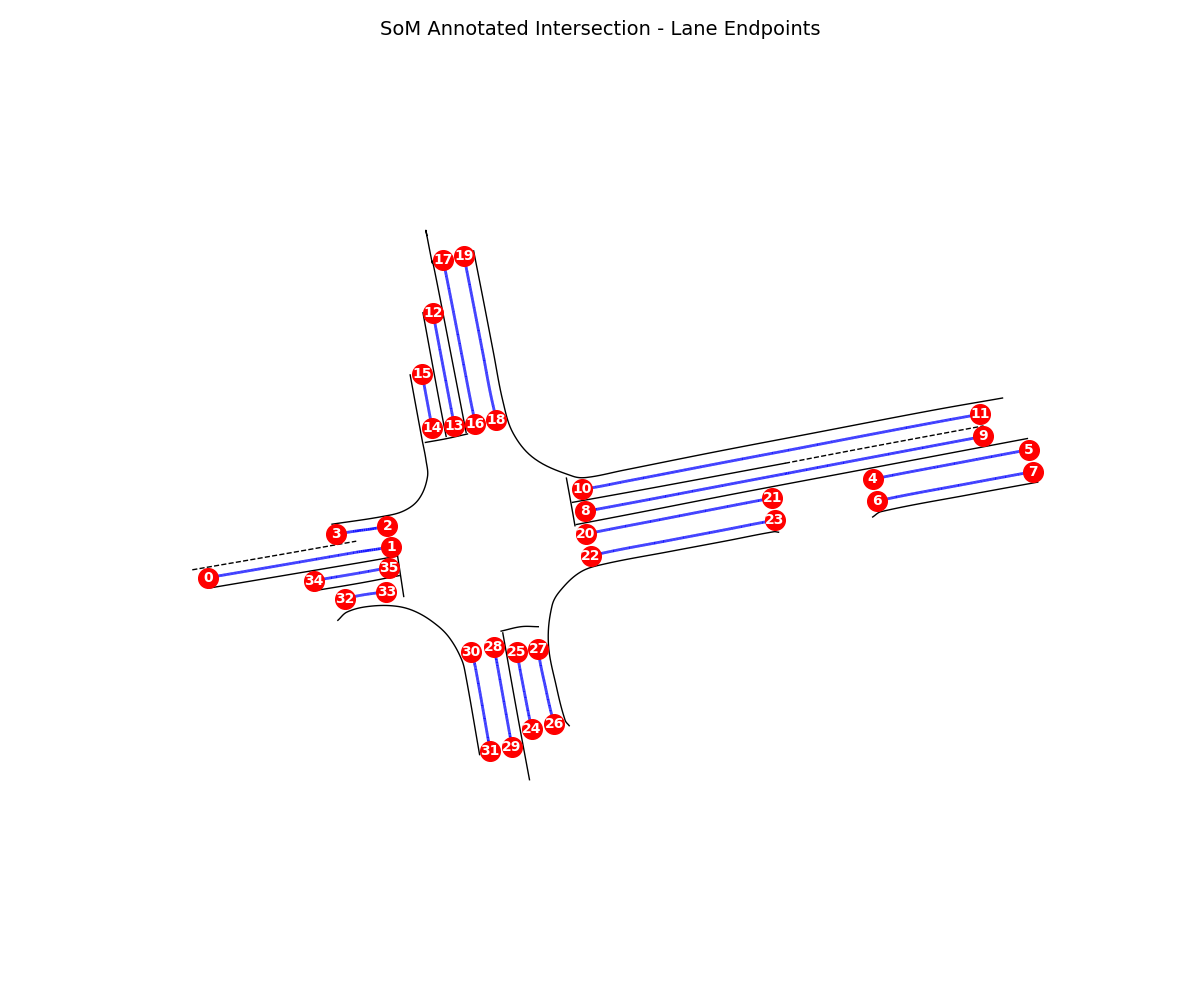


Marked endpoints:
  [1] Lane 0, pos=(-16.8, -40.2)
  [2] Lane 1, pos=(-19.0, -28.1)
  [4] Lane 2, pos=(267.1, -0.4)
  [5] Lane 2, pos=(359.5, 17.1)
  [6] Lane 3, pos=(270.0, -13.3)
  [7] Lane 3, pos=(361.9, 4.1)
  [8] Lane 4, pos=(97.6, -19.4)
  [9] Lane 4, pos=(332.5, 24.9)
  [10] Lane 5, pos=(95.9, -6.2)
  [11] Lane 5, pos=(330.4, 37.9)
  [13] Lane 6, pos=(20.6, 31.1)
  [14] Lane 7, pos=(7.5, 29.7)
  [16] Lane 8, pos=(33.0, 32.1)
  [17] Lane 8, pos=(13.9, 128.7)
  [18] Lane 9, pos=(45.3, 34.8)
  [19] Lane 9, pos=(26.2, 131.2)
  [20] Lane 10, pos=(98.1, -32.7)
  [21] Lane 10, pos=(208.0, -11.5)
  [22] Lane 11, pos=(100.9, -45.6)
  [23] Lane 11, pos=(209.4, -24.7)
  [24] Lane 12, pos=(66.2, -147.8)
  [25] Lane 12, pos=(57.5, -102.4)
  [26] Lane 13, pos=(79.4, -144.8)
  [27] Lane 13, pos=(70.0, -100.6)
  [28] Lane 14, pos=(43.7, -99.1)
  [29] Lane 14, pos=(54.6, -158.2)
  [30] Lane 15, pos=(30.4, -102.4)
  [31] Lane 15, pos=(41.7, -160.6)
  [32] Lane 16, pos=(-43.9, -70.9)
  [33] Lane 

In [13]:
# ============================================================================
# SoM PROMPTING: Lane Connection Identification via VLM
# ============================================================================
# This cell uses Set-of-Mark prompting to identify lane connections at intersections

from som import (
    extract_lane_endpoints,
    create_annotated_figure,
    identify_lane_connections,
    draw_connections,
)

# First, visualize the annotated figure with numbered markers (without VLM)
endpoints, intersection_ids = extract_lane_endpoints(
    centerline_segments,
    cluster_radius=25.0,  # Adjust based on intersection size
)

print(f"Total endpoints: {len(endpoints)}")
print(f"Intersection endpoints: {len(intersection_ids)}")

if intersection_ids:
    # Create and display the annotated figure
    som_fig = create_annotated_figure(
        scene["roadway"],
        centerline_segments,
        endpoints,
        intersection_ids,
        figsize=(12, 10),
        marker_size=200,
        font_size=10,
    )
    som_fig.suptitle("SoM Annotated Intersection - Lane Endpoints", fontsize=14)
    plt.show()
    
    # Print endpoint info
    print("\nMarked endpoints:")
    for ep in endpoints:
        if ep.id in intersection_ids:
            print(f"  [{ep.id}] Lane {ep.lane_idx}, pos=({ep.x:.1f}, {ep.y:.1f})")
else:
    print("No intersection detected - endpoints don't cluster from multiple lanes")

Extracted 36 total endpoints from centerlines
LaneEndpoint(id=0, x=np.float64(-124.558934242044), y=np.float64(-58.430454626764956), heading=np.float64(-2.972356289656633), lane_idx=0)


APIConnectionError: Connection error.

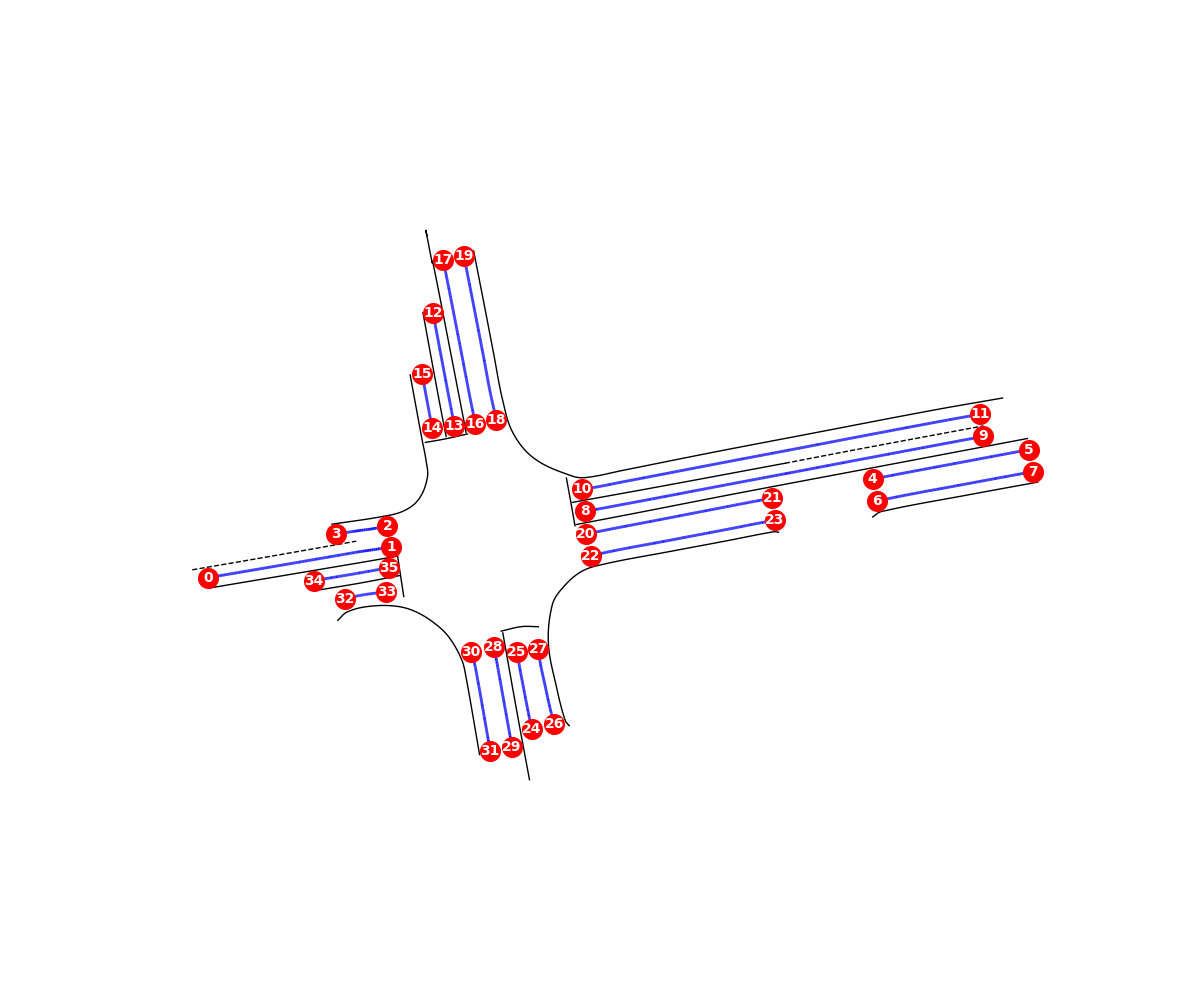

In [14]:
# ============================================================================
# VLM Query for Lane Connections (requires API key)
# ============================================================================
# Uncomment and configure to query the VLM


# Configuration - adjust these for your setup
VLM_CONFIG = {
    # For local Qwen via llama-server:
    # "base_url": "http://192.168.68.70:8000/v1",
    "base_url": "http://localhost:8080/v1",
    # "model": "Qwen/Qwen3-VL-32B-Thinking-FP8",
    "model": "Qwen3-VL-32B-Thinking-Q8_0.gguf",
    # "model": "Qwen3-VL-30B-A3B-Instruct-AWQ",
    "api_key": "not-needed",  # llama-server doesn't require auth
    
    # For OpenAI GPT-4o:
    # "base_url": "https://api.openai.com/v1",
    # "model": "gpt-4o",
    # "api_key": os.environ.get("OPENAI_API_KEY"),
}



# Uncomment to run the VLM query:
result_som = identify_lane_connections(
    roadway=scene["roadway"],
    centerlines=centerline_segments,
    api_key=VLM_CONFIG["api_key"],
    base_url=VLM_CONFIG["base_url"],
    model=VLM_CONFIG["model"],
    cluster_radius=25.0,
    debug=True,
)

print(f"Identified {len(result_som['connections'])} connections:")
for conn in result_som['connections']:
    print(f"  {conn.from_id} -> {conn.to_id}")

if result_som.get('raw_response'):
    print(f"\nRaw VLM response:\n{result_som['raw_response']}")

Curves: 23/23 collision-free


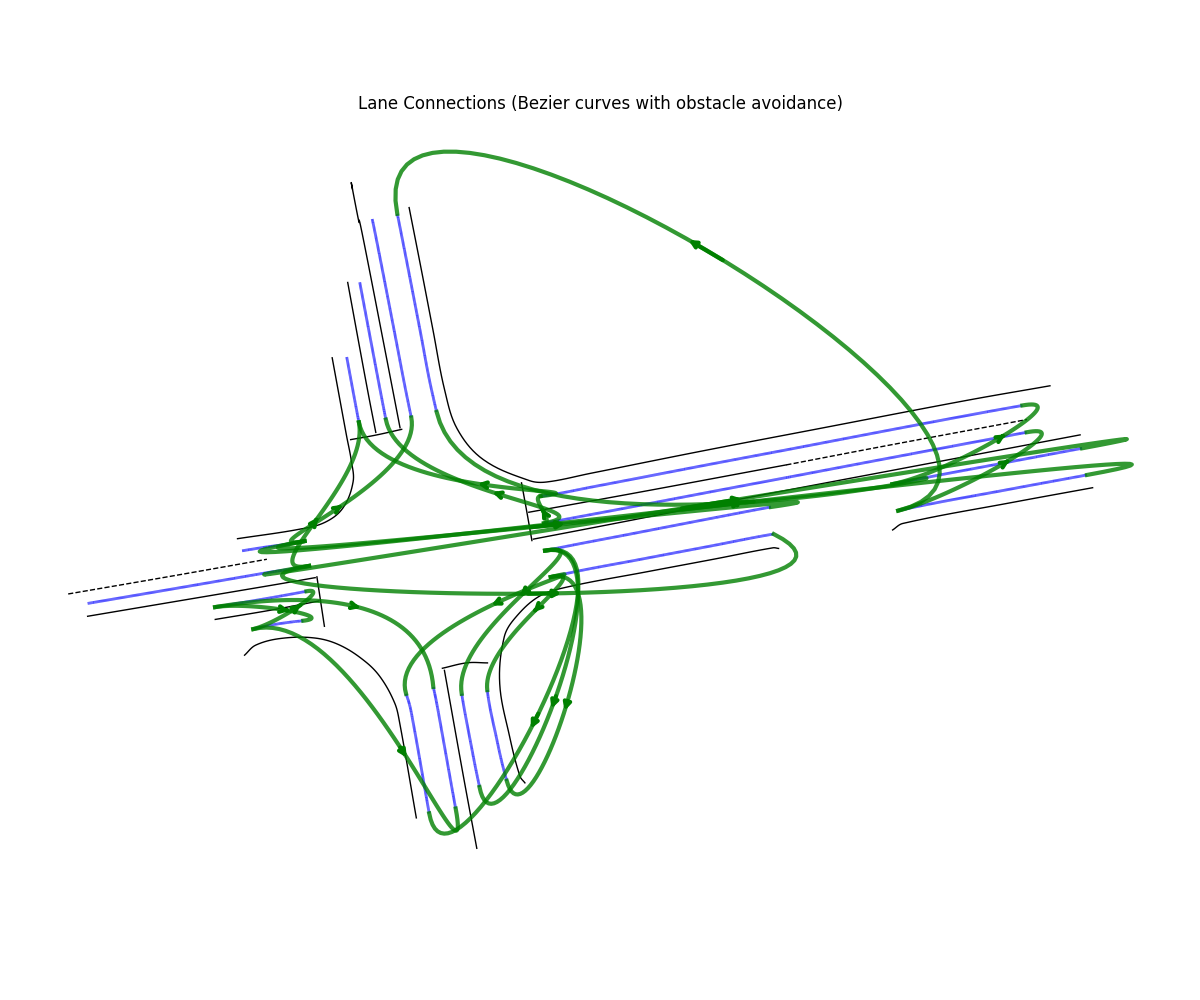

In [ ]:
# ============================================================================
# Visualize Lane Connections with Bezier Curves
# ============================================================================
# Run this after the VLM query cell above

# Uncomment after running VLM query:
if 'result_som' in dir() and result_som.get('connections'):
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Draw roadway
    for item in scene["roadway"]:
        verts = item["verts"]
        xs, ys = zip(*verts)
        dashed = item.get("dashed", False)
        closed = item.get("closed", False)
        if dashed:
            ax.plot(xs, ys, color='black', linestyle='--', linewidth=1)
        else:
            ax.plot(xs, ys, color='black', linewidth=1)
            if closed:
                ax.fill(xs, ys, color='lightgray', alpha=0.5)
    
    # Draw centerlines
    from matplotlib.collections import LineCollection
    segments = []
    for lane in centerline_segments:
        for i in range(len(lane) - 1):
            x0, y0, _ = lane[i]
            x1, y1, _ = lane[i + 1]
            segments.append([[x0, y0], [x1, y1]])
    lc = LineCollection(segments, color='blue', linewidths=2, alpha=0.7, zorder=5)
    ax.add_collection(lc)
    
    # Draw connections with Bezier curves and obstacle avoidance
    curve_data = draw_connections(
        ax,
        result_som['connections'],
        result_som['endpoints'],
        roadway=scene["roadway"],
        color='green',
        linewidth=3,
        alpha=0.8,
        use_bezier=True,
        avoid_obstacles=True,
    )
    
    # Report collision status
    collision_free_count = sum(1 for v in curve_data.values() if v['collision_free'])
    print(f"Curves: {collision_free_count}/{len(curve_data)} collision-free")
    
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.set_title('Lane Connections (Bezier curves with obstacle avoidance)')
    plt.tight_layout()
    plt.show()
else:
    print("Run the VLM query cell first to get connections")